In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Background nucleosome-score windows (see analysis code for calculation)
nuc_array_path = "binding_score_at_motifs/background_nucleosome_arrays/global_nuc_bg_prom_n7.npy"

# Background binding-score windows (see analysis code for calculation)
erg_bg_windows_path = "binding_score_at_motifs/background_binding_arrays/ERG__orig-human__loc-prom__signal_bg__fl25.npy"

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

In [4]:
# Load background nucleosome score windows
nuc_array = np.load(nuc_array_path, mmap_mode=None)

# Load ERG background binding-score windows
erg_bg_windows = np.load(erg_bg_windows_path, mmap_mode=None)
erg_bg_raw   = erg_bg_windows[:,0]
erg_bg_z     = erg_bg_windows[:,1]

## Plotting

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Plot ERG background signal histograms across nucleosome bins
def plot_erg_hist_by_nuc_z3_per_dist(
    erg_bg_raw,
    nuc_array,
    bins=50,
    bar_color="#0B3D91",
):
    erg_bg_raw = np.asarray(erg_bg_raw)
    nuc_array = np.asarray(nuc_array)

    # log2-transform (drop non-positive values)
    valid = erg_bg_raw > 0
    erg_log2 = np.full_like(erg_bg_raw, np.nan, dtype=float)
    erg_log2[valid] = np.log2(erg_bg_raw[valid])

    # three nuc bins
    masks = [
        (nuc_array < 0.5) & valid,
        (nuc_array >= 0.5) & (nuc_array <= 1) & valid,
        (nuc_array > 1) & valid,
    ]
    labels = ["Nuc. score\n< 0.5", "0.5 ≤ Nuc.\nscore ≤ 1", "Nuc. score\n> 1"]

    fig, axes = plt.subplots(
        3, 1, figsize=(5, 7), sharex=True,
        gridspec_kw={"hspace": 0.08}  # closer stacking
    )

    for ax, m, lab in zip(axes, masks, labels):
        x = erg_log2[m]
        x = x[np.isfinite(x)]

        # density histogram
        ax.hist(x, bins=bins, density=True, color=bar_color)

        # inline label (instead of title)
        ax.text(1.06, 0.5, lab, transform=ax.transAxes,
                ha="center", va="center", fontsize=12, rotation=270)

        # compute Z within THIS distribution and find x at Z=3
        if x.size >= 2:
            mu = float(np.mean(x))
            sigma = float(np.std(x, ddof=1))  # sample std
            if np.isfinite(sigma) and sigma > 0:
                x_z3 = mu + 3.0 * sigma

                ax.axvline(x_z3, color="#8FB6FF", linewidth=2)

                ymax = ax.get_ylim()[1]
                ax.text(
                    x_z3+0.2, ymax * 0.5,
                    f"Z=3",
                    ha="left", va="top", fontsize=12
                )
            else:
                ax.text(0.98, 0.92, "σ=0 (no Z line)", transform=ax.transAxes,
                        ha="right", va="top", fontsize=9)
        else:
            ax.text(0.98, 0.92, "n<2 (no Z line)", transform=ax.transAxes,
                    ha="right", va="top", fontsize=9)

        ax.set_ylabel("Density", fontsize=12)

    axes[-1].set_xlabel("log2(mean background window signal)", fontsize=12)

    plt.tight_layout()
    plt.show()

<ipython-input-5-e8cc0a50fe1c>:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


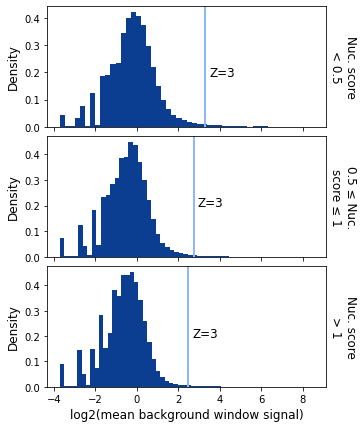

In [6]:
# Generate the requested histogram plot
plot_erg_hist_by_nuc_z3_per_dist(erg_bg_raw, nuc_array, bins=50)